# Import

In [1]:
import numpy as np
import seaborn as sns
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np
import plotly.graph_objs as go
from ipywidgets import widgets, HBox, VBox, Output
import sympy as sp
from sympy import symbols, Function, Eq, Derivative, expand, collect, simplify
from sympy import Piecewise, sqrt

sns.set(style="white")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# Tools functions

In [2]:
# Generate the stock price paths
def generate_BM_path_func(**params):

    X = np.zeros((params['n_paths'], params['n_steps'] + 1))
    X[:,0] = params['S_0']
    dW = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))
    t_ = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))

    dW[:,1:] = np.random.normal(loc=0, scale=np.sqrt(params['T']/params['n_steps']), size=(params['n_paths'], params['n_steps']))
    t_[:,:] = np.linspace(0, params['T'], params['n_steps'] + 1)

    W = np.cumsum(dW, axis=1)

    # Geometric BM
    #X = params['S_0']*np.exp(params['sigma']*W + (params['rate']-0.5*(params['sigma']**2))*t_)

    # Arithmetic BM
    for i in range(1, params['n_steps'] + 1):
        X[:, i] = X[:, i-1] + params['sigma']*dW[:, i]

    return X, t_

In [3]:
def amm_paths_func(**params):

    a0, a1, a2 = params['a0'], params['a1'], params['a2']#1, 30, 10

    ksi = params['ksi'] #3

    # Initialisation
    X0 = params['X0'] #10**6 # USD
    Y0 = params['Y0'] #10**3 # USD

    c = X0*Y0

    step_size = params['T']/params['n_steps']

    # Constant product function
    phi_func = lambda x : c/x
    d_phi_func = lambda x : -c/(x**2)

    # Intensity functions
    intensity_a = lambda Y, Z, S : np.maximum(a0, a1 + a2*(S-Z))
    intensity_b = lambda Y, Z, S : np.maximum(a0, a1 + a2*(Z-S))

    # Fees function
    r_fees = lambda Y, Z : 0.01*Z

    # Generate exteral stock price paths
    S, t_ = generate_BM_path_func(**params)

    X = np.zeros_like(S)
    Y = np.zeros_like(S)
    Z = np.zeros_like(S)
    R = np.zeros_like(S) # Fees function
    Na, Nb = np.zeros_like(S), np.zeros_like(S)

    Na[:, 0], Nb[:, 0] = 0, 0
    Y[:, 0] = Y0
    X[:, 0] = X0
    Z[:, 0] = X[:, 0]/Y[:, 0]

    # Generate path
    for i in range(1, params['n_steps'] + 1):

        # Update Na and Nb: Jump times
        lambda_a = intensity_a(Y[:, i-1], Z[:, i-1], S[:, i])
        lambda_b = intensity_b(Y[:, i-1], Z[:, i-1], S[:, i])

        # If 1/lambda  equivalent to step_size, maybe more than one jump during the step
        u_a = np.random.uniform(0,1, size=params['n_paths'])
        u_b = np.random.uniform(0,1, size=params['n_paths'])

        dNa_i = (u_a <= lambda_a * step_size)*1
        dNb_i = (u_b <= lambda_b * step_size)*1

        Na[:, i] = dNa_i
        Nb[:, i] = dNb_i

        Y[:, i] = Y[:, i-1] + ksi*dNb_i - ksi*dNa_i
        X[:, i] = X[:, i-1] + (phi_func(Y[:, i-1]+ksi) - phi_func(Y[:, i-1]))*dNb_i + (phi_func(Y[:, i-1]-ksi) - phi_func(Y[:, i-1]))*dNa_i
        Z[:, i] = Z[:, i-1] + (-d_phi_func(Y[:, i-1]+ksi) + d_phi_func(Y[:, i-1]))*dNb_i + (-d_phi_func(Y[:, i-1]-ksi) + d_phi_func(Y[:, i-1]))*dNa_i

        #R[:, i] = R[:, i-1] + r_fees(Y[:, i-1], Z[:, i-1])*(dNa_i + dNb_i)
        R[:, i] = R[:, i-1] + r_fees(Y[:, i-1], X0/Y0)*(dNa_i + dNb_i)

    return X, Y, Z, R, S, t_

In [4]:
# Longstaff-Scwartz algorithm
def longstaff_schwartz_func(paths, fitting_method, deg, discount_factor=1):

    optimal_tau_matrix = np.zeros_like(paths)

    n_steps = paths.shape[1] - 1
    n_paths = paths.shape[0]

    # Initialisation and terminal condition (which is 0 for our AMM problem)
    V = np.zeros_like(paths)

    # Stopping time matrix
    tau_matrix = np.zeros_like(paths)
    tau_matrix[:, -1] = 1 # If never optimal, we consider that the option is exercised at maturity

    # Loop for backward induction
    for i in range(n_steps - 1, 0, -1):

        X_i = paths[:, i]
        Y_i = V[:, i+1]*discount_factor

        if fitting_method == 'standard': 
            P = np.polynomial.polynomial.Polynomial.fit(x=X_i, y=Y_i, deg=deg)
        elif fitting_method == 'laguerre':
            P = np.polynomial.laguerre.Laguerre.fit(x=X_i, y=Y_i, deg=deg)
        elif fitting_method == 'hermite':
            P = np.polynomial.hermite.Hermite.fit(x=X_i, y=Y_i, deg=deg)

        stop_here_ti = (X_i >= P(X_i))
        V[:, i] = stop_here_ti*X_i + (1-stop_here_ti)*V[:, i+1]*discount_factor

        tau_matrix[:, i] = np.where(stop_here_ti, 1, 0)

    # Get a matrix of 1 when exercise for each path and 0 elsewhere
    optimal_tau_matrix[np.arange(n_paths), np.argmax(tau_matrix, axis=1)] = 1
    
    # Compute the value of the optimal stopping time problem
    V0 = (1/n_paths)*np.sum(V[:,1]*discount_factor)

    return V0, optimal_tau_matrix

# Monte Carlo Approximation

## Parameters

In [5]:
# Parameters

sigma = 0.2*10**3
rate = 0.05

T = 1

strike = 1.1*10**3
S_0 = 10**3

n_paths = 5000
n_steps = 500
step_size = T / n_steps

a0, a1, a2 = 1, 30, 10

ksi = 3

X0 = 10**6 # USD
Y0 = 10**3 # USD

discount_factor = np.exp(-rate*step_size)

gamma = 10**(-8)

deg = 3
fitting_method = 'hermite'

params = {'n_paths': n_paths, 'n_steps': n_steps, 'S_0': S_0, 'sigma': sigma, 'rate': rate, 'T': T, 'a0': a0, 'a1': a1, 'a2': a2, 'ksi': ksi, 'X0': X0, 'Y0': Y0}

option_type = 'call'

# Define payoff function
if option_type == 'call':
    g = lambda X, K : np.maximum(X-K,0)
elif option_type == 'put':
    g = lambda X, K : np.maximum(K-X,0)
else:
    raise ValueError

In [6]:
X, Y, Z, R, S, t_ = amm_paths_func(**params)

## European Option

In [7]:
# European Call Option price by Monte Carlo

Option_MC = np.mean(np.exp(-rate*T)*g(S[:,-1], strike))

IC = np.array([-1.96,1.96])*np.sqrt(np.var(np.exp(-rate*T)*g(S[:,-1], strike))/n_steps)

print(f"EU {option_type} option price by Monte Carlo: {round(Option_MC,2)} and confidence interval is {round(float(Option_MC+IC[0]),2),round(float(Option_MC+IC[1]),2)}")

EU call option price by Monte Carlo: 36.03 and confidence interval is (29.35, 42.72)


In [8]:
# Exact solution

d_plus = (np.log(S_0/strike) + (rate + 0.5*sigma**2)*T) * (1/(sigma*np.sqrt(T)))
d_minus = d_plus - sigma*np.sqrt(T)

Call_Exact = S_0*norm.cdf(d_plus) - strike*np.exp(-rate*T)*norm.cdf(d_minus)
Put_Exact = - S_0*norm.cdf(-d_plus) + strike*np.exp(-rate*T)*norm.cdf(-d_minus)

print(f"EU Call option price by closed form formula: {Call_Exact}")
print(f"EU Put option price by closed form formula: {Put_Exact}")

EU Call option price by closed form formula: 1000.0
EU Put option price by closed form formula: 1046.3523669507854


## Amercian Option

/opt/anaconda3/envs/env0823/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/opt/anaconda3/envs/env0823/lib/python3.11/site-packages/numpy/polynomial/polyutils.py:303: RuntimeWarning: divide by zero encountered in scalar divide
  off = (old[1]*new[0] - old[0]*new[1])/oldlen
/opt/anaconda3/envs/env0823/lib/python3.11/site-packages/numpy/polynomial/polyutils.py:304: RuntimeWarning: divide by zero encountered in scalar divide
  scl = newlen/oldlen
/opt/anaconda3/envs/env0823/lib/python3.11/site-packages/numpy/polynomial/polyutils.py:372: RuntimeWarning: invalid value encountered in add
  return off + scl*x


Error at step 10 --> SVD did not converge in Linear Least Squares** On entry to DGELSD, parameter number  4 had an illegal value

Error at step 8 --> SVD did not converge in Linear Least Squares
** On entry to DGELSD, parameter number  4 had an illegal value
US call option price by Longstaff-Schwartz: 0.0


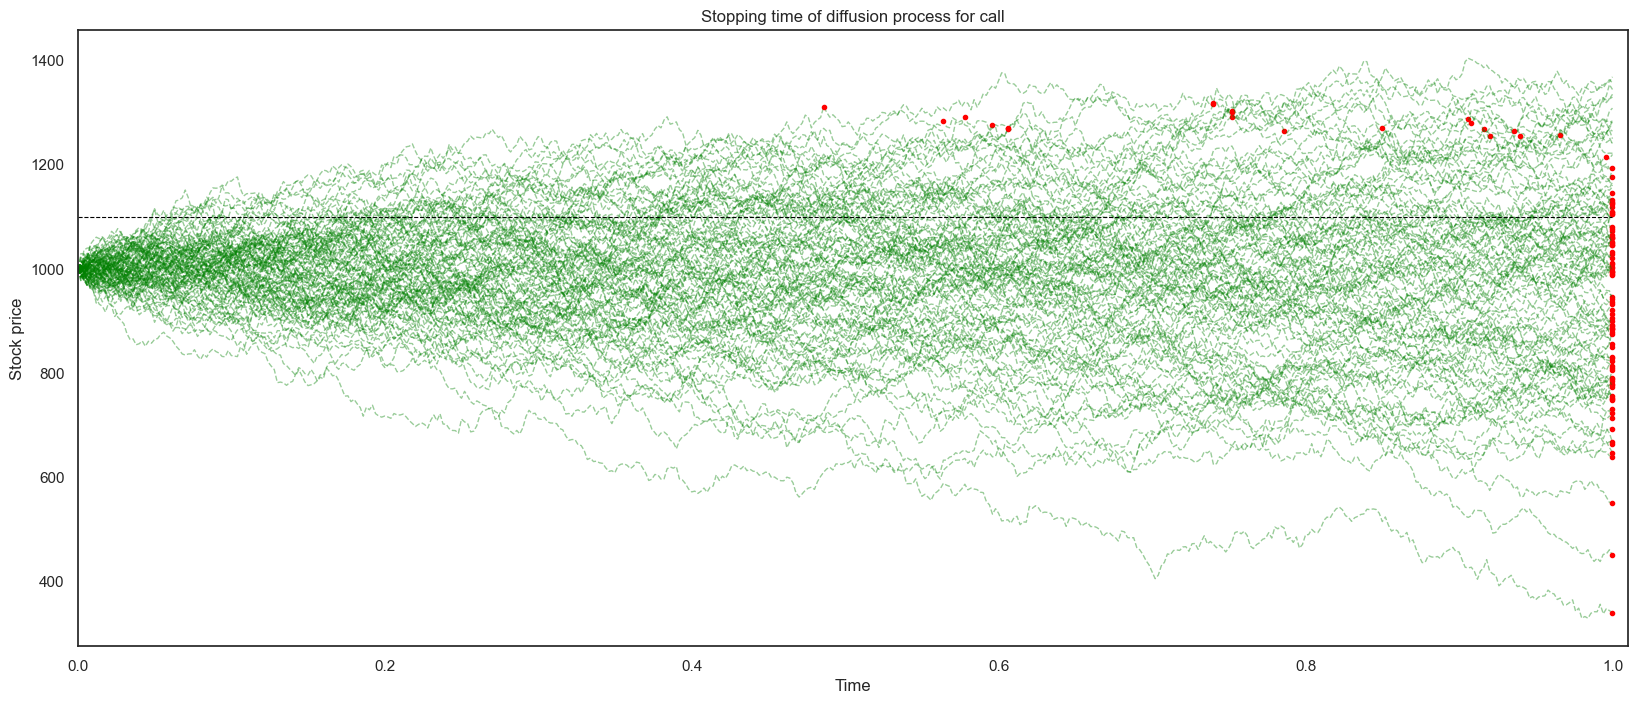

In [9]:
# Initialisation
l = 2 # Degree of Laguerre/Standard polynomials // Dimension of the L2 basis
fitting_method = 'standard' # 'standard', 'laguerre', 'hermite'


V = np.zeros(shape=(n_paths, n_steps + 1))


# Define the terminal condition
V[:,-1] = g(S[:,-1], strike)

# Stopping time matrix
tau_matrix = np.zeros(shape=(n_paths, n_steps + 1))
tau_matrix[:, -1] = 1 # If never exercized, we consider that the option is exercised at maturity

# Loop for backward induction
for i in range(n_steps - 1, 0, -1):

    try:
        # Identify In The Money paths
        ITM = g(S[:, i], strike) > 0

        # Regression only on ITM paths
        if np.sum(ITM) > 0:    
            S_i_ITM = S[ITM, i]
            Y_i_ITM = V[ITM, i+1]*discount_factor

            if fitting_method == 'standard':
                P = np.polynomial.polynomial.Polynomial.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)
            elif fitting_method == 'laguerre':
                P = np.polynomial.laguerre.Laguerre.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)
            elif fitting_method == 'hermite':
                P = np.polynomial.hermite.Hermite.fit(x=S_i_ITM, y=Y_i_ITM, deg=l)

            stop_here_ITM_ti =  (g(S_i_ITM, strike) > P(S_i_ITM)) # Stop here is applied on ITM paths
            V[ITM, i] = stop_here_ITM_ti*g(S_i_ITM, strike) + (1-stop_here_ITM_ti)*V[ITM, i+1]*discount_factor

            tau_matrix[ITM, i] = np.where(stop_here_ITM_ti, 1, 0)

        # Discount OTM paths
        V[~ITM, i] = V[~ITM, i+1]*discount_factor

    except Exception as e:
        print(f"Error at step {i} --> {e}")

# Get the first time the option is exercised for each path
stopping_time = np.argmax(tau_matrix,axis=1)

V0 = (1/n_paths)*np.sum(V[:,1]*discount_factor)
print(f"US {option_type} option price by Longstaff-Schwartz: {round(V0,4)}")  

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100

for j in np.random.randint(0, high=n_paths, size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(stopping_time[j])], S[j, int(stopping_time[j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=T+10**(-2))
ax.hlines(y=strike, xmin=0, xmax=T, color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

## AMM Simulation Process

### Raw simulation

In [10]:
# Full path

P_X = X - X0
P_Y = Y - Y0

amm_paths = P_X + S*P_Y + R
amm_paths_utility = -np.exp(-gamma*(P_X + S*P_Y + R))

In [11]:
amm_price, amm_tau_matrix = longstaff_schwartz_func(amm_paths_utility, fitting_method, deg)
amm_stopping_time_index = amm_tau_matrix@np.arange(n_steps + 1)

### GUI

In [12]:
# Fixed parameters
n_paths, n_steps = 5000, 500
fitting_method, deg = 'standard', 3

# Generate 3D data that depends on multiple parameters
def generate_data(sigma, rate, T, a0, a1, a2, ksi, X0, Y0, S_0):

    params = {'n_paths': n_paths, 'n_steps': n_steps, 'S_0': S_0, 'sigma': sigma, 'rate': rate, 'T': T, 'a0': a0, 'a1': a1, 'a2': a2, 'ksi': ksi, 'X0': X0, 'Y0': Y0}

    # Generate paths of the AMM
    X, Y, Z, R, S, t_ = amm_paths_func(**params)
    
    P_X = X - X0
    P_Y = Y - Y0
    amm_paths = P_X + S*P_Y + R

    # Generate the optimal stopping time across all trajectories
    _, amm_tau_matrix = longstaff_schwartz_func(amm_paths, fitting_method, deg)
    amm_stopping_time_index = (amm_tau_matrix@np.arange(n_steps + 1)).astype(int)
    
    return X, Y, Z, R, S, t_, amm_stopping_time_index

# Create an output widget to display the plot
plot_output = Output()

# Create a function to plot the 3D data based on multiple parameters
def plot_3d_system(sigma, rate, T, a0, a1, a2, ksi, X0, Y0, S0, snapshot_time, selected_x, selected_y, selected_z):
    X, Y, Z, R, S, t_, amm_stopping_time_index = generate_data(sigma, rate, T, a0, a1, a2, ksi, X0, Y0, S0)
    
    # Map variable names to actual arrays
    array_map = {
        'X': X,
        'Y': Y,
        'Z': Z,
        'R': R,
        'S': S,
        'S-Z': S-Z,
        't_': t_
    }

    idx = np.argwhere(amm_stopping_time_index <= snapshot_time)
    
    # Get the data for X, Y, Z axes based on dropdown selections
    x_data = array_map[selected_x][idx, amm_stopping_time_index[idx]].flatten()
    y_data = array_map[selected_y][idx, amm_stopping_time_index[idx]].flatten()
    z_data = array_map[selected_z][idx, amm_stopping_time_index[idx]].flatten()

    # Create the 3D plot
    trace = go.Scatter3d(
        x=x_data if len(x_data) > 0 else [0],
        y=y_data if len(y_data) > 0 else [0],
        z=z_data if len(z_data) > 0 else [0],
        mode='markers',
        marker=dict(
            size=2,
        )
    )
    
    annotations = [
                dict(
                text=f'Initial local price : 1 ETH = {X0/Y0} USDC',
                x=0, y=0.05,  # Annotation position (adjust if needed)
                xref="paper", yref="paper",
                showarrow=False,
                font=dict(size=14, color="red"),
                align="center",
                bgcolor="white",
                opacity=0.8
            ),
            dict(
                text=f'S-Z value switch from baseline intensity : {str((a0-a1)/a2) + str(' USDC') if a2 != 0 else 'a2 = 0'}',
                x=0, y=0,  # Annotation position (adjust if needed)
                xref="paper", yref="paper",
                showarrow=False,
                font=dict(size=14, color="blue"),
                align="center",
                bgcolor="white",
                opacity=0.8
            )
]

    layout = go.Layout(
        title="3D System Evolution with Multiple Parameters",
        scene=dict(
            xaxis=dict(title=f'{selected_x}', range=[np.min(x_data), np.max(x_data)]),
            yaxis=dict(title=f'{selected_y}', range=[np.min(y_data), np.max(y_data)]),
            zaxis=dict(title=f'{selected_z}', range=[np.min(z_data), np.max(z_data)])
        ),
        margin=dict(l=0, r=0, b=10, t=30),
        width=800,
        height=700,
        annotations=annotations
    )
    
    fig = go.Figure(data=[trace], layout=layout)
    
    # Clear previous output and display the new plot
    with plot_output:
        plot_output.clear_output(wait=True)
        fig.show()

# Create dropdowns for selecting the array to plot on the X, Y, and Z axes
array_options = ['X', 'Y', 'Z', 'R', 'S', 'S-Z', 't_']

x_dropdown = widgets.Dropdown(
    options=array_options,
    value='R',  # Default value
    description='Select X:',
)

y_dropdown = widgets.Dropdown(
    options=array_options,
    value='t_',  # Default value
    description='Select Y:',
)

z_dropdown = widgets.Dropdown(
    options=array_options,
    value='S-Z',  # Default value
    description='Select Z:',
)

# Create sliders for different parameters
sigma_slider = widgets.FloatSlider(value=0.2*10**3, min=0.1*10**3, max=1.0*10**3, step=10, description='sigma:')
rate_slider = widgets.FloatSlider(value=0.05, min=0, max=0.1, step=0.01, description='rate:')
T_slider = widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.1, description='T:')
a0_slider = widgets.FloatSlider(value=5, min=0, max=50, step=0.5, description='a0:')
a1_slider = widgets.FloatSlider(value=30, min=0, max=50, step=0.5, description='a1:')
a2_slider = widgets.FloatSlider(value=10, min=0, max=50, step=0.5, description='a2:')
ksi_slider = widgets.FloatSlider(value=3, min=1, max=10, step=0.5, description='ksi:')
X0_slider = widgets.FloatSlider(value=100_000, min=10_000, max=1_000_000, step=10, description='X0:')
Y0_slider = widgets.FloatSlider(value=100, min=10, max=1_000, step=10, description='Y0:')
S0_slider = widgets.FloatSlider(value=1000, min=10, max=100_000, step=10, description='S0:')
refresh_button = widgets.Button(description="Refresh Plot")

# Create a slider for selecting the snapshot time
snapshot_time_slider = widgets.IntSlider(value=n_steps, min=0, max=n_steps, step=1, description='Snapshot:')

# Group all the axis selection widgets
axis_selection = VBox([
    widgets.HTML(value="<b>Axis Selection</b>"),
    x_dropdown,
    y_dropdown,
    z_dropdown
])

# Group all the parameter widgets
parameters = VBox([
    widgets.HTML(value="<b>Model Parameters</b>"),
    sigma_slider,
    rate_slider,
    T_slider,
    a0_slider,
    a1_slider,
    a2_slider,
    ksi_slider,
    X0_slider,
    Y0_slider,
    S0_slider,
    refresh_button
])

# Group snapshot and rotation controls
visualization_controls = VBox([
    widgets.HTML(value="<b>Visualization Controls</b>"),
    snapshot_time_slider,
])

# Group all widgets into a single vertical box for the left side
all_widgets = VBox([axis_selection, parameters, visualization_controls], 
                  layout=widgets.Layout(width='500px'))

# Create a function to update the plot when widget values change
def update_plot(*args):
    plot_3d_system(
        sigma_slider.value, 
        rate_slider.value, 
        T_slider.value, 
        a0_slider.value, 
        a1_slider.value, 
        a2_slider.value, 
        ksi_slider.value, 
        X0_slider.value, 
        Y0_slider.value,
        S0_slider.value,
        snapshot_time_slider.value,
        x_dropdown.value, 
        y_dropdown.value, 
        z_dropdown.value,
    )

# Connect the update function to all widgets
sigma_slider.observe(update_plot, names='value')
rate_slider.observe(update_plot, names='value')
T_slider.observe(update_plot, names='value')
a0_slider.observe(update_plot, names='value')
a1_slider.observe(update_plot, names='value')
a2_slider.observe(update_plot, names='value')
ksi_slider.observe(update_plot, names='value')
X0_slider.observe(update_plot, names='value')
Y0_slider.observe(update_plot, names='value')
S0_slider.observe(update_plot, names='value')
snapshot_time_slider.observe(update_plot, names='value')
x_dropdown.observe(update_plot, names='value')
y_dropdown.observe(update_plot, names='value')
z_dropdown.observe(update_plot, names='value')

refresh_button.on_click(lambda _: update_plot())

# Put widgets on the left and plot on the right in a horizontal box
layout = HBox([all_widgets, plot_output])

# Initialize the plot
update_plot()

# Display the layout
display(layout)

SyntaxError: f-string: unmatched '(' (3608141290.py, line 71)

In [13]:

## Remarks
# Trade size has an influence on the optimal stopping time
# A low sigma value gives just noise in the optimal stopping time
# A high sigma value gives shapes




# Idea : plot how the intensity change over time on all trajectories

# Euler method

In [ ]:
Y0 = 10**3 # BTC
S_0 = 10**3 # USD
X0 = Y0*S_0 #USD

strike = 10**3 # USD # Testing option pricer with a strike price of 1000 USD

delta = 0.01
h = 10
T = 1 # 1 day
ksi = 3
sigma = 0.3/np.sqrt(35)*S_0 # 30% annual volatility --> 0.3/np.sqrt(365) daily volatility
a0, a1, a2 = 0, 0, 0

c = X0*Y0

scale_factor = 0.5

# Constant product function
phi_func = lambda y : c/y

# Fees function
r_fees = lambda Z : 0.1*Z

# Grid (time, space, jumps)
time_discretization = np.arange(0, T + delta, delta)
S_matrix = np.arange((1-scale_factor)*S_0, (1+scale_factor)*S_0 + h, h)
y_matrix = np.arange(ksi, max(ksi, int(2*a1*T)*ksi) + ksi, ksi)

# Jumps intensities
intensity_a = lambda y, S : np.maximum(a0, a1 + a2*(S-c/(y**2)))
intensity_b = lambda y, S : np.maximum(a0, a1 + a2*(c/(y**2)-S))

# Coefficient of the linear system
c_0_func = lambda y, S : 1 + delta*(intensity_a(y,S) + intensity_b(y,S))
c_2_func = lambda y, S : 1 + delta*((1/h**2)*sigma**2 + intensity_a(y,S) + intensity_b(y,S))
c_1 = -(1/(2*h**2))*delta*(sigma**2)

In [15]:
# Backward scheme

I = time_discretization.shape[0] - 1
L = y_matrix.shape[0] - 1
J = S_matrix.shape[0] - 1

V_matrix = np.zeros(shape=(I + 1, L + 1, J + 1))

# Terminal condition
V_matrix[-1, :, :] = np.maximum(0, S_matrix - strike) # Call option payoff

for i in range(I - 1, -1, -1): # From I - 1 to 0
    print(f'Time: {i}', end=' ')
    for l in range(0, L+1): # From 0 to L

        # Neumann boundary conditions: second derivative is 0   
        c_0_0 = c_0_func(y_matrix[l], S_matrix[0]) # v(t_{i+1}, y_l, S_0)
        c_0_J = c_0_func(y_matrix[l], S_matrix[-1]) # v(t_{i+1}, y_l, S_J})
        
        c_2 = c_2_func(y_matrix[l], S_matrix[1:-1]) # v(t_{i+1}, y_l, S_1), ..., v(t_{i+1}, y_l, S_J-1)

        # Define the linear system
        A_c_2 = np.diag(np.concatenate((np.array([c_0_0]), c_2, np.array([c_0_J]))), k=0) # diagonal
        A_c_1 = np.diag(np.ones(shape=(J,))*c_1, k=1) # upper diagonal
        A_c_3 = np.diag(np.ones(shape=(J,))*c_1, k=-1) # lower diagonal

        A = A_c_1 + A_c_2 + A_c_3
        A[0, 1] = 0
        A[-1, -2] = 0

        # Solve the linear system --> know v(t_i, y_l, S_j) for all j
        V_matrix[i, l, :] = np.linalg.solve(A, V_matrix[i+1, l, :]) 
        
        if L == 0: # No jumps
            pass

        elif l == 0:
            # Adjust v(t_i, y_l, S_j) --> know v(t_i, y_l, S_j) for all l and j
            V_matrix[i, l, :] += -1*(V_matrix[i, l+1, :]*intensity_a(y_matrix[l], S_matrix) \
                                + intensity_b(y_matrix[l], S_matrix)*(phi_func(y_matrix[l+1])-phi_func(y_matrix[l])+ksi*S_matrix+r_fees(c/(y_matrix[l]**2))))
        elif l == L:
            # Adjust v(t_i, y_l, S_j) --> know v(t_i, y_l, S_j) for all l and j
            V_matrix[i, l, :] += -1*(V_matrix[i, l-1, :]*intensity_b(y_matrix[l], S_matrix) \
                                + intensity_a(y_matrix[l], S_matrix)*(phi_func(y_matrix[l-1])-phi_func(y_matrix[l])-ksi*S_matrix+r_fees(c/(y_matrix[l]**2)))) \
        
        else:
            # Adjust v(t_i, y_l, S_j) --> know v(t_i, y_l, S_j) for all l and j
            V_matrix[i, l, :] += -1*(V_matrix[i, l+1, :]*intensity_a(y_matrix[l], S_matrix) \
                                + V_matrix[i, l-1, :]*intensity_b(y_matrix[l], S_matrix) \
                                + intensity_a(y_matrix[l], S_matrix)*(phi_func(y_matrix[l-1])-phi_func(y_matrix[l])-ksi*S_matrix+r_fees(c/(y_matrix[l]**2))) \
                                + intensity_b(y_matrix[l], S_matrix)*(phi_func(y_matrix[l+1])-phi_func(y_matrix[l])+ksi*S_matrix+r_fees(c/(y_matrix[l]**2))))
    print('---> Done')

Time: 99 ---> Done
Time: 98 ---> Done
Time: 97 ---> Done
Time: 96 ---> Done
Time: 95 ---> Done
Time: 94 ---> Done
Time: 93 ---> Done
Time: 92 ---> Done
Time: 91 ---> Done
Time: 90 ---> Done
Time: 89 ---> Done
Time: 88 ---> Done
Time: 87 ---> Done
Time: 86 ---> Done
Time: 85 ---> Done
Time: 84 ---> Done
Time: 83 ---> Done
Time: 82 ---> Done
Time: 81 ---> Done
Time: 80 ---> Done
Time: 79 ---> Done
Time: 78 ---> Done
Time: 77 ---> Done
Time: 76 ---> Done
Time: 75 ---> Done
Time: 74 ---> Done
Time: 73 ---> Done
Time: 72 ---> Done
Time: 71 ---> Done
Time: 70 ---> Done
Time: 69 ---> Done
Time: 68 ---> Done
Time: 67 ---> Done
Time: 66 ---> Done
Time: 65 ---> Done
Time: 64 ---> Done
Time: 63 ---> Done
Time: 62 ---> Done
Time: 61 ---> Done
Time: 60 ---> Done
Time: 59 ---> Done
Time: 58 ---> Done
Time: 57 ---> Done
Time: 56 ---> Done
Time: 55 ---> Done
Time: 54 ---> Done
Time: 53 ---> Done
Time: 52 ---> Done
Time: 51 ---> Done
Time: 50 ---> Done
Time: 49 ---> Done
Time: 48 ---> Done
Time: 47 ---

In [16]:
# Create a 3D surface plot for each jump
fig = go.Figure()

for jump in np.arange(0, L+1):

    fig.add_trace(go.Scatter(x=S_matrix, y=V_matrix[0, jump, :], mode='markers', name=f'y_{jump}'))

# Update layout for better visualization
fig.update_layout(
    title="Value Function at t=0",
    xaxis_title="Stock Price",
    yaxis_title="Value function at t=0",
)

# Show the plot
fig.show()

### 3D Plot animation

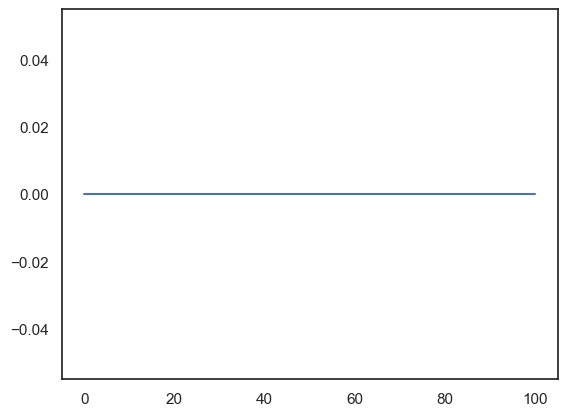

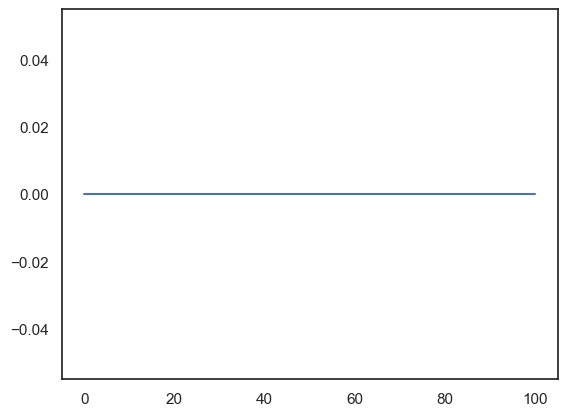

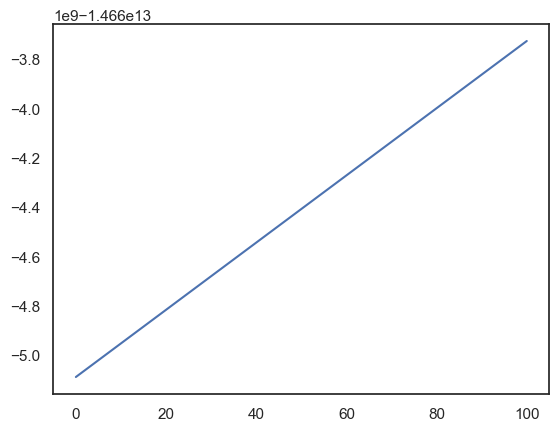

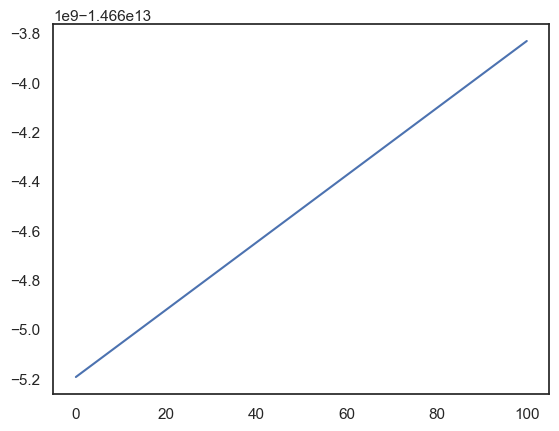

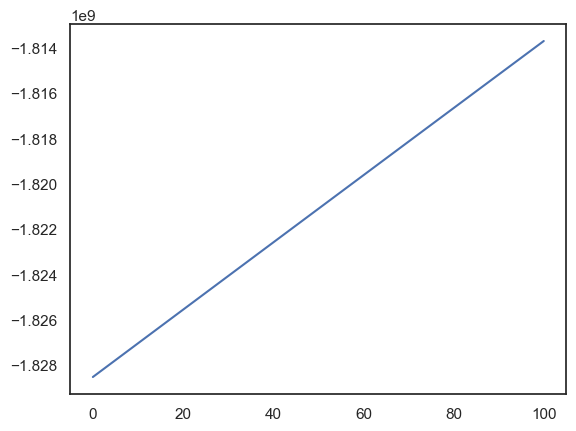

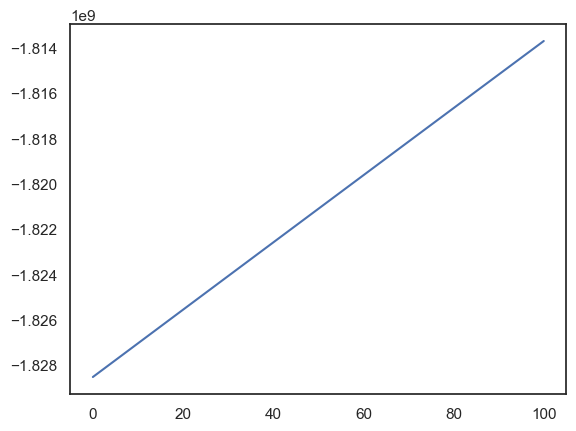

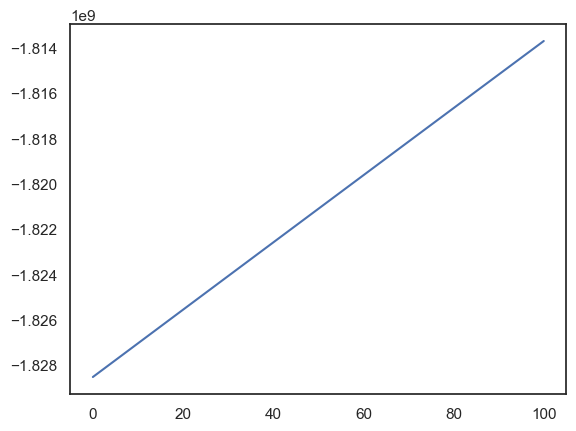

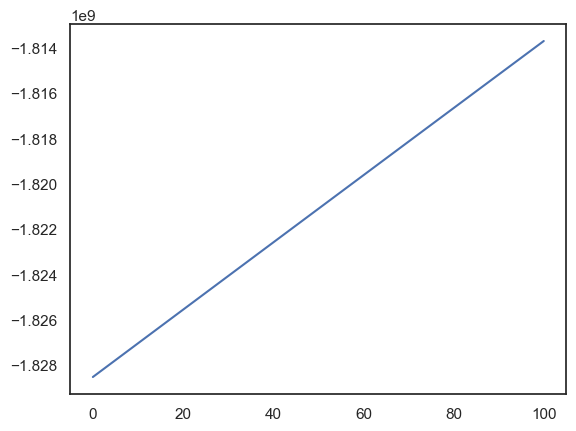

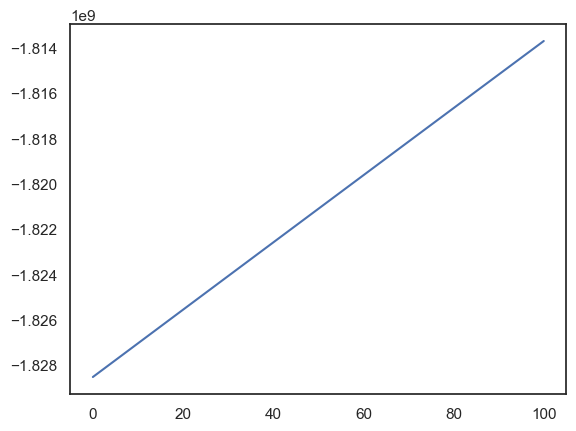

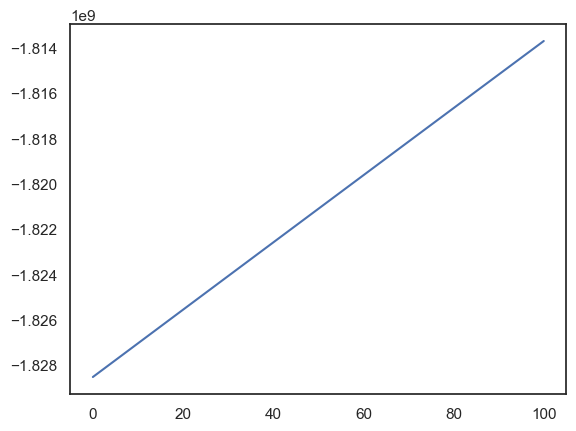

In [ ]:
# Output widget for the plot
plot_output = Output()

# Constant product function
def phi_func(x, c):
    return c / x

def r_fees(Z):
    return 0.1 * Z

# Data generation function
def generate_option_data(sigma, T, a0, a1, a2, ksi, X0, Y0, S0):
    delta = 0.01
    h = 10
    c = X0 * Y0
    scale_factor = 0.5

    time_discretization = np.arange(0, T + delta, delta)
    S_matrix = np.arange((1-scale_factor)*S0, (1+scale_factor)*S0 + h, h)
    y_matrix = np.arange(ksi, max(3*ksi, int(2*np.maximum(a0,a1)*T)*ksi) + ksi, ksi)

    intensity_a = lambda y, S: np.maximum(a0, a1 + a2 * (S - c / (y**2)))
    intensity_b = lambda y, S: np.maximum(a0, a1 + a2 * (c / (y**2) - S))

    c_0_func = lambda y, S: 1 + delta * (intensity_a(y,S) + intensity_b(y,S))
    c_2_func = lambda y, S: 1 + delta * ((1/h**2)*sigma**2 + intensity_a(y,S) + intensity_b(y,S))
    c_1 = -(1/(2*h**2)) * delta * (sigma**2)

    I = time_discretization.shape[0] - 1
    L = y_matrix.shape[0] - 1
    J = S_matrix.shape[0] - 1

    V_matrix = np.zeros((I + 1, L + 1, J + 1))
    V_matrix[-1, :, :] = 0 #np.maximum(0, S_matrix - strike)

    for i in range(I - 1, -1, -1):
        for l in range(0, L + 1):
            c_0_0 = c_0_func(y_matrix[l], S_matrix[0])
            c_0_J = c_0_func(y_matrix[l], S_matrix[-1])
            c_2 = c_2_func(y_matrix[l], S_matrix[1:-1])

            A_c_2 = np.diag(np.concatenate(([c_0_0], c_2, [c_0_J])), k=0)
            A_c_1 = np.diag(np.ones(J) * c_1, k=1)
            A_c_3 = np.diag(np.ones(J) * c_1, k=-1)
            A = A_c_1 + A_c_2 + A_c_3
            A[0, 1] = 0
            A[-1, -2] = 0

            V_temp = V_matrix[i+1, l, :]

            if l > 0:
                V_temp += (
                    intensity_a(y_matrix[l], S_matrix) * (phi_func(y_matrix[l-1], c) - phi_func(y_matrix[l], c) - ksi*S_matrix + r_fees(c/(y_matrix[l]**2)))
                )
            if l < L:
                V_temp +=  (
                    intensity_b(y_matrix[l], S_matrix) * (phi_func(y_matrix[l+1], c) - phi_func(y_matrix[l], c) + ksi*S_matrix + r_fees(c/(y_matrix[l]**2)))
                )

            V_matrix[i, l, :] = np.linalg.solve(A, V_temp)

    # Prepare 3D data for a snapshot
    S_grid, Y_grid = np.meshgrid(S_matrix, y_matrix)
    Z_grid = V_matrix[0, :, :]
    plt.plot(V_matrix[-2, int(L/2), :])
    plt.show()
    return S_grid.flatten(), Y_grid.flatten(), Z_grid.flatten()

# Plot function
def plot_option_system(sigma, T, a0, a1, a2, ksi, X0, Y0, S0):
    x_data, y_data, z_data = generate_option_data(sigma, T, a0, a1, a2, ksi, X0, Y0, S0)

    trace = go.Scatter3d(x=x_data, y=y_data, z=z_data, mode='markers', marker=dict(size=2))
    layout = go.Layout(
        title="Option Value Surface",
        scene=dict(
            xaxis=dict(title='Asset Price S'),
            yaxis=dict(title='Jump y'),
            zaxis=dict(title='Value function V'),
        ),
        margin=dict(l=0, r=0, b=10, t=30),
        width=800,
        height=700
    )
    fig = go.Figure(data=[trace], layout=layout)
    with plot_output:
        plot_output.clear_output(wait=True)
        fig.show()

# Sliders and controls
sigma_slider = widgets.FloatSlider(value=100.0, min=10, max=500, step=10, description='sigma:')
T_slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='T:')
a0_slider = widgets.FloatSlider(value=0, min=0, max=20, step=1, description='a0:')
a1_slider = widgets.FloatSlider(value=0, min=0, max=50, step=1, description='a1:')
a2_slider = widgets.FloatSlider(value=0, min=0, max=1e-1, step=1e-2, description='a2:')
ksi_slider = widgets.FloatSlider(value=3, min=1, max=10, step=0.5, description='ksi:')
X0_slider = widgets.FloatSlider(value=1e6, min=1e5, max=2e6, step=1e4, description='X0:')
Y0_slider = widgets.FloatSlider(value=1e3, min=100, max=1e4, step=100, description='Y0:')
S0_slider = widgets.FloatSlider(value=1e3, min=500, max=1e5, step=100, description='S0:')
refresh_button = widgets.Button(description="Refresh Plot")

# Update function
def update_plot(*args):
    plot_option_system(
        sigma_slider.value,
        T_slider.value,
        a0_slider.value,
        a1_slider.value,
        a2_slider.value,
        ksi_slider.value,
        X0_slider.value,
        Y0_slider.value,
        S0_slider.value,
    )

for widget in [sigma_slider, T_slider, a0_slider, a1_slider, a2_slider, ksi_slider, X0_slider, Y0_slider, S0_slider]:
    widget.observe(update_plot, names='value')
refresh_button.on_click(lambda _: update_plot())

# Layout and display
controls = VBox([sigma_slider, T_slider, a0_slider, a1_slider, a2_slider, ksi_slider, X0_slider, Y0_slider, S0_slider, refresh_button])
layout = HBox([controls, plot_output])
update_plot()
display(layout)


In [ ]:
# Extract the time slice for t=0 (first time step)
V_slice = V_matrix[0, :, :]  # This is of shape (jumps, space)

# Create meshgrid for jumps and space (corresponding to x and y axes)
jumps, space = np.meshgrid(np.arange(V_slice.shape[0]), np.arange(V_slice.shape[1]))

# Create 3D surface plot
fig = go.Figure(data=[go.Surface(
    z=V_slice,  # The values at t=0
    x=jumps,    # Corresponds to jumps (x-axis)
    y=space,    # Corresponds to space (y-axis)
    colorscale='Viridis',  # You can choose any color scale
    colorbar=dict(title="Value")  # Colorbar showing the values
)])

# Set plot titles and labels
fig.update_layout(
    title="Evolution of V[0,:,:] (Time=0) with Jumps and Space",
    scene=dict(
        xaxis_title='Jumps',
        yaxis_title='Space',
        zaxis_title='Value'
    ),
    width=800,
    height=700
    )

# Show the plot
fig.show()

# Symbolic calculus

In [ ]:

# Define the symbols
t, y, s, xi, c, r = symbols('t y s xi c r')

# Time-dependent coefficient functions
v1, v2, v3, v4, v5, v6 = [Function(f'v{i}')(t) for i in range(1, 7)]

# Define the ansatz
v = v1 + v2 * y + v3 * s + v4 * y * s + v5 * y**2 + v6 * s**2

# Define the partial derivatives
dv_t = Derivative(v, t)
dv_ss = Derivative(v, s, 2)

# Define the auxiliary functions bar_lambda_a and bar_lambda_b
a0, a1, a2 = symbols('a0 a1 a2')
lambda_a = Piecewise((a0, a0 >= a1 + a2 * (y - sqrt(c/y))),(a1 + a2 * (y - sqrt(c/y)), True))
lambda_b = Piecewise((a0, a0 >= a1 + a2 * (sqrt(c/y) - y)),(a1 + a2 * (sqrt(c/y) - y), True))

# The remaining terms involving bar_lambda_b and bar_lambda_a
jump_b = lambda_a * (xi * c / (y * (y - xi)) - xi * s + r + v.subs(y, y + xi) - v)
jump_a = lambda_b * (-xi * c / (y * (y + xi)) + xi * s + r + v.subs(y, y - xi) - v)


In [ ]:
# The terms in the PDE
lhs = dv_t + (1/2) * (symbols('sigma')**2) * dv_ss

# The full PDE
pde = Eq(lhs + jump_b + jump_a, 0)

# Expand and collect terms (optional but useful for analysis)
expanded = simplify(expand(pde.lhs))

# If desired: collect by monomials (y, s, y*s, etc.)
collected = collect(expanded, [1, y, s, y*s, y**2, s**2])

collected

In [ ]:
pde

In [ ]:
collected.items()

In [ ]:
# Print each collected term as a coefficient equation (i.e., set equal to 0)
for monomial, coeff in collected.items():
    print("Monomial:", monomial)
    print("Coefficient Equation: ")
    print(Eq(coeff, 0))
    print()